In [ ]:
data= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/potential-talents - Aspiring human resources - seeking human resources.csv')

In [ ]:
df=data.copy()

In [ ]:
df.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [ ]:
df.shape

(104, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


In [ ]:
df.describe()

,id,fit
count,104.000000,0.0
mean,52.500000,NaN
std,30.166206,NaN
min,1.000000,NaN
25%,26.750000,NaN
50%,52.500000,NaN
75%,78.250000,NaN
max,104.000000,NaN


In [ ]:
df.describe(include='object')

,job_title,location,connection
count,104,104,104
unique,52,41,33
top,2019 C.T. Bauer College of Business Graduate (...,Kanada,500+
freq,7,12,44


In [ ]:
df.isnull().sum()

,0
id,0
job_title,0
location,0
connection,0
fit,104


In [ ]:
print("\n2. Categorical Columns:")
print("\nValue counts for 'job_title' column (top 10):")
print(df['job_title'].value_counts().head(10))

print("\nValue counts for 'location' column (top 10):")
print(df['location'].value_counts().head(10))

print("\nValue counts for 'connection' column:")
print(df['connection'].value_counts())


2. Categorical Columns:

Value counts for 'job_title' column (top 10):
job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional    7
Aspiring Human Resources Professional                                                                       7
Student at Humber College and Aspiring Human Resources Generalist                                           7
People Development Coordinator at Ryan                                                                      6
Native English Teacher at EPIK (English Program in Korea)                                                   5
Aspiring Human Resources Specialist                                                                         5
HR Senior Specialist                                                                                        5
Advisory Board Member at Celal Bayar University                                                             4
Seeking Human Resources HRIS and Gener

### Word Cloud of Processed Job Titles

Vocabulary size: 200
Top 10 features (words) learned: ['2019', 'bauer', 'college', 'of', 'business', 'graduate', 'magna', 'cum', 'laude', 'and']
Shape of the document-term matrix: (104, 200)

Sample of Document-Term Matrix (first 5 rows, first 10 columns):
 [[1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]]


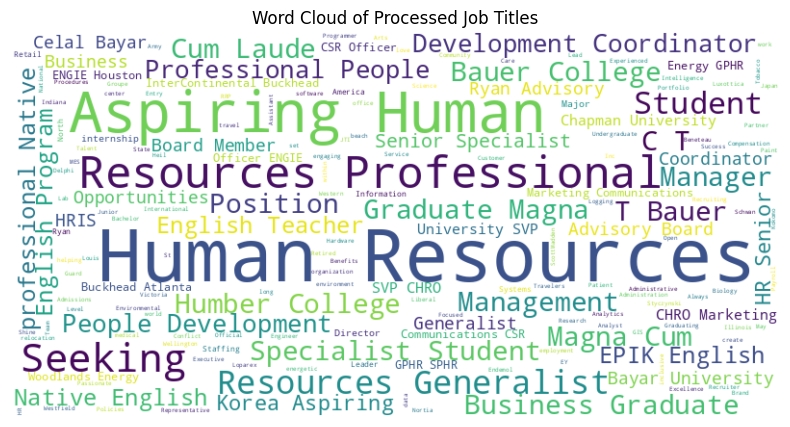

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

vectorizer = CountVectorizer(max_features=2000) # You can adjust max_features as needed

# Fit and transform the processed job titles
X_count_vectorized = vectorizer.fit_transform(df['job_title'])

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Top 10 features (words) learned:", list(vectorizer.vocabulary_.keys())[:10])
print("Shape of the document-term matrix:", X_count_vectorized.shape)

# Display a sample of the document-term matrix (e.g., for the first 5 documents)
# This converts the sparse matrix to a dense array for display
print("\nSample of Document-Term Matrix (first 5 rows, first 10 columns):\n", X_count_vectorized[:5, :10].toarray())

# Generate Word Cloud
# Combine all processed job title strings into one large text
all_words = ' '.join([text for text in df['job_title']])

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Processed Job Titles')
plt.show()

### Most Frequent Words in Job Titles using CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Initialize CountVectorizer
# You can adjust parameters like max_features, min_df, max_df, ngram_range
count_vectorizer = CountVectorizer(max_features=1000) # Limiting features to 1000 for demonstration

# Fit and transform the job titles
X_count = count_vectorizer.fit_transform(df['job_title'])

print("Shape of CountVectorizer matrix:", X_count.shape)

# Get feature names (words)
feature_names = count_vectorizer.get_feature_names_out()

# Sum the counts for each feature across all documents
word_counts = X_count.sum(axis=0)

# Create a DataFrame of words and their counts
word_freq_df = pd.DataFrame({'word': feature_names, 'count': word_counts.tolist()[0]})

# Sort by count in descending order
word_freq_df = word_freq_df.sort_values(by='count', ascending=False)

print("\nTop 20 most frequent words in job titles:")
print(word_freq_df.head(50))


Shape of CountVectorizer matrix: (104, 200)

Top 20 most frequent words in job titles:
                 word  count
155         resources     63
84              human     63
20                 at     46
18           aspiring     35
15                and     28
146      professional     20
174           student     16
163           seeking     15
71         generalist     14
38            college     14
169        specialist     12
189        university     12
127                of     11
32           business     11
59            english     10
87                 in     10
43        coordinator     10
46                cum      7
0                2019      7
23              bauer      7
74           graduate      7
117           manager      7
114             magna      7
103             laude      7
85             humber      7
116        management      7
82                 hr      6
50        development      6
159              ryan      6
164            senior      6
140           

# Preprocess Text
* Converting text to lowercase.
* Breaking the text into individual words (tokens) using word_tokenize.
* Filters out words that are not alphabetic, removes stop words, and applies lemmatization to the remaining words. This helps standardize the text and focus on meaningful terms.
* Replacing HR with Human Resources.





In [ ]:
# Install gensim if not already installed
!pip install gensim

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim.models

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    # Explicitly download 'punkt_tab' as suggested by the error
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
# It initializes a WordNetLemmatizer to reduce words to their base form (e.g., 'running' to 'run') and loads a set of common English stop_words (like 'the', 'is', 'a') that are usually removed during text processing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

word_map = {
    "hr": "human resources",
    "recruiter": "human resources",
    "talent acquisition": "human resources",
}

def normalize_text(text):
    text = text.lower()
    for k, v in word_map.items():
        text = text.replace(k, v)
    return text

df['job_title_clean'] = df['job_title'].apply(normalize_text)
print("Job titles normalized and stored in 'job_title_clean' column.")
df[['job_title', 'job_title_clean']].head()

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    tokens = word_tokenize(text)  # Tokenize
    # Remove stopwords, lemmatize, and remove non-alphabetic tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Apply preprocessing to the 'job_title_clean' column (after user's normalization)
df['processed_job_title'] = df['job_title_clean'].apply(preprocess_text)
df[['job_title', 'processed_job_title']].head()

Job titles normalized and stored in 'job_title_clean' column.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,job_title,processed_job_title
0,2019 C.T. Bauer College of Business Graduate (...,"[bauer, college, business, graduate, magna, cu..."
1,Native English Teacher at EPIK (English Progra...,"[native, english, teacher, epik, english, prog..."
2,Aspiring Human Resources Professional,"[aspiring, human, resource, professional]"
3,People Development Coordinator at Ryan,"[people, development, coordinator, ryan]"
4,Advisory Board Member at Celal Bayar University,"[advisory, board, member, celal, bayar, univer..."


# **Embedding**

## Word2Vec
* Two-layer neural network technique used in natural language processing (NLP) to produce dense vector representations of words, capturing semantic and syntactic relationships.  It places words with similar meanings close together in a high-dimensional vector space by predicting a target word from its surrounding context (CBOW- Continuous Bag of Words) or predicting context words from a target word (Skip-gram).

In [ ]:
# Train Word2Vec model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW.

word2vec_model = gensim.models.Word2Vec(sentences=df['processed_job_title'],
                                        vector_size=100,
                                        window=5,
                                        min_count=2,
                                        workers=4,
                                        sg=0)

In [ ]:
# Function to create document embedding by averaging word vectors
def get_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary
# Apply the get_average_embedding function to each list of tokens
df['job_title_embedding'] = df['processed_job_title'].apply(lambda tokens: get_document_embedding(tokens, word2vec_model))
df[['job_title', 'job_title_embedding']].head()

,job_title,job_title_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[0.0016742188, 0.0002734413, 0.0018166878, 0.0..."
1,Native English Teacher at EPIK (English Progra...,"[-4.727114e-05, -0.003282718, 0.0021956472, -0..."
2,Aspiring Human Resources Professional,"[-0.004372496, 0.0039762342, 0.00075248437, 0...."
3,People Development Coordinator at Ryan,"[0.0029596265, 0.0020586422, 0.003301497, -0.0..."
4,Advisory Board Member at Celal Bayar University,"[0.0008259456, -0.004887592, -0.0020814978, 0...."


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_job_titles(query_job_title, df, word2vec_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_document_embedding(processed_query, word2vec_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['id', 'job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage:
query = "Aspiring Human Resources"
recommended_jobs = recommend_job_titles(query, df, word2vec_model, top_n=df.shape[0])

print(f"Recommendations for '{query}':\n")
display(recommended_jobs[:10])



Recommendations for 'Aspiring Human Resources':



,id,job_title,location,connection,similarity
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
23,24,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
35,36,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
48,49,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693


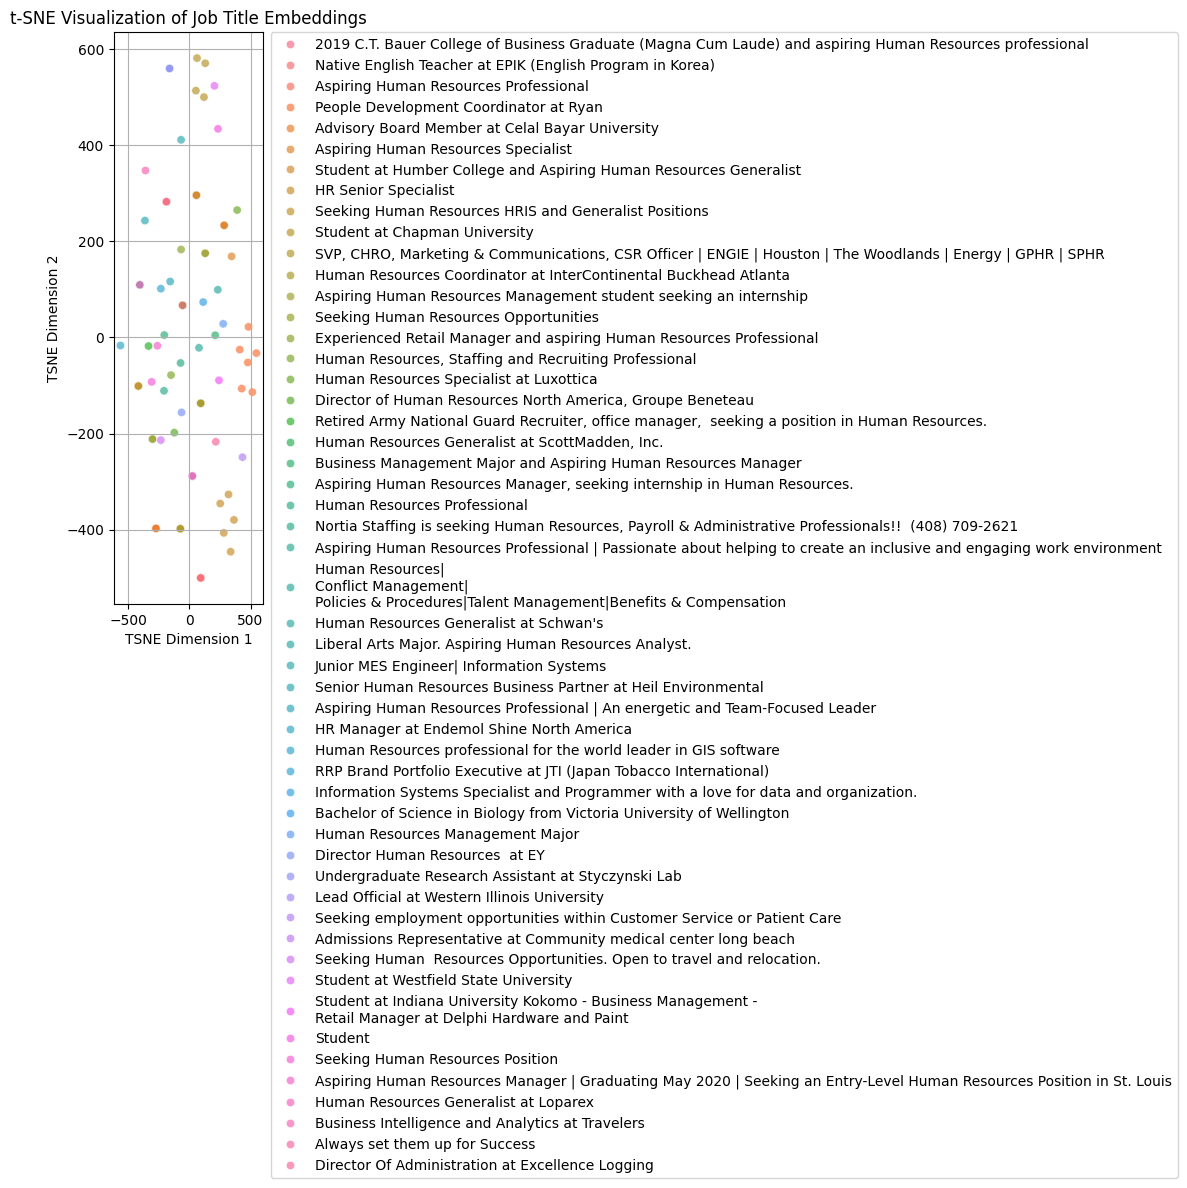

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for t-SNE
# Convert the 'job_title_embedding' series of arrays into a 2D numpy array
embeddings_array = np.array(df['job_title_embedding'].tolist())

# Initialize t-SNE model
# We'll reduce to 2 dimensions for easy plotting
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings_array) - 1))

# Fit and transform the embeddings
embeddings_2d = tsne.fit_transform(embeddings_array)

# Create a DataFrame for plotting
embeddings_df = pd.DataFrame(embeddings_2d, columns=['TSNE_Dim1', 'TSNE_Dim2'])
embeddings_df['job_title'] = df['job_title'] # Add original job titles for reference

# Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='TSNE_Dim1', y='TSNE_Dim2',
    hue='job_title', # Color points by job title (or a simplified category if too many unique titles)
    data=embeddings_df,
    legend='full',
    alpha=0.7
)

plt.title('t-SNE Visualization of Job Title Embeddings')
plt.xlabel('TSNE Dimension 1')
plt.ylabel('TSNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Place legend outside
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
recommended_jobs['similarity'].describe()

,similarity
count,104.000000
mean,0.415081
std,0.325060
min,-0.092223
25%,0.068564
50%,0.535449
75%,0.695965
max,0.884659


# **Learning to Rank Models**

## Creating Fit column

**Reasoning**:
To create the initial 'fit' column, I need to extract the 'similarity' scores from the 'recommended_jobs' DataFrame, normalize them to a 0-1 range, and then assign these normalized scores to the 'fit' column in the original 'df' DataFrame. I will use the 'id' column to correctly map the scores.



In [ ]:
df_updated = df.copy()

# Create a temporary DataFrame with 'id' and 'similarity' from recommended_jobs
similarity_df = recommended_jobs[['id', 'similarity']]

# Merge this with the original DataFrame 'df' to align similarities by 'id'
df_updated = pd.merge(df_updated, similarity_df, on='id', how='left')

# Normalize the 'similarity' scores to a 0-1 range using the formula (score + 1) / 2
df_updated['fit'] = (df_updated['similarity'] + 1) / 2

# Drop the temporary 'similarity' column if not needed further
df_updated = df_updated.drop(columns=['similarity'])

df = df_updated # Update the main dataframe

print("Initial 'fit' column created and normalized in 'df'.")
df[['id', 'job_title', 'fit']].sort_values(by='fit', ascending=False).head(15)

Initial 'fit' column created and normalized in 'df'.


,id,job_title,fit
5,6,Aspiring Human Resources Specialist,0.942330
23,24,Aspiring Human Resources Specialist,0.942330
35,36,Aspiring Human Resources Specialist,0.942330
48,49,Aspiring Human Resources Specialist,0.942330
59,60,Aspiring Human Resources Specialist,0.942330
20,21,Aspiring Human Resources Professional,0.928346
16,17,Aspiring Human Resources Professional,0.928346
2,3,Aspiring Human Resources Professional,0.928346
45,46,Aspiring Human Resources Professional,0.928346
57,58,Aspiring Human Resources Professional,0.928346


### Train- Test Split
Extract the 'fit' column as the target variable y, split the feature matrix X and target variable y into training and testing sets (X_train, X_test, y_train, y_test), and define query groups for both the training and testing sets for Learning to Rank models.

In [ ]:
y = df_updated['fit']
X = df['job_title_embedding']

In [ ]:
y = df_updated['fit']
X = df['job_title_embedding']
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (83,)
X_test shape: (21,)
y_train shape: (83,)
y_test shape: (21,)


## Train XGBRanker Model



In [ ]:
import xgboost as xgb

# Convert X_train (Series of arrays) to a 2D NumPy array
X_train_array = np.array(X_train.tolist())

# Initialize XGBRanker model
xgb_ranker_model = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
     # Often faster for larger datasets
)

# Train the model
# group_train represents the query groups. Since we are treating all items as part of one large query for initial training,
# group_train will be a list containing the total number of training samples.
xgb_ranker_model.fit(X_train_array, y_train, qid=np.zeros(len(X_train_array)))

print("XGBRanker model trained successfully.")

XGBRanker model trained successfully.


## Evaluate XGBRanker Model

### Subtask:
Evaluate the trained XGBRanker model on the test data  using NDCG@k and MAP@k metrics. This will assess how well the model ranks candidates based on their predicted 'fit' scores.

In [ ]:
from sklearn.metrics import ndcg_score, average_precision_score

# Convert X_test (Series of arrays) to a 2D NumPy array
X_test_array = np.array(X_test.tolist())

# Predict ranking scores on the test set
xgb_pred_scores = xgb_ranker_model.predict(X_test_array)

# Calculate NDCG and MAP. Since we trained with a single query group, we'll evaluate similarly.
# For NDCG and MAP, we expect ground truth relevance scores (y_test) and predicted scores.
# Note: sklearn's ndcg_score expects y_true and y_score to be 2D arrays if there are multiple queries.
# For a single query, we can pass them as 1D and wrap them in a list for ndcg_score.

# NDCG@k
xgb_ndcg = ndcg_score([y_test.values], [xgb_pred_scores])

# MAP (Mean Average Precision)
# For a single query, Average Precision is calculated directly.
xgb_map = average_precision_score(y_test.values > 0, xgb_pred_scores) # Using y_test > 0 as binary relevance for MAP

print(f"XGBRanker NDCG: {xgb_ndcg}")
print(f"XGBRanker MAP: {xgb_map}")

XGBRanker NDCG: 0.9936026045667239
XGBRanker MAP: 1.0


In [ ]:
test_results_df = df.loc[X_test.index, ['id', 'job_title', 'connection']].copy()
test_results_df['xgb_predicted_score'] = xgb_pred_scores
display(test_results_df.sort_values(by='xgb_predicted_score', ascending=False).head(10))

,id,job_title,connection,xgb_predicted_score
35,36,Aspiring Human Resources Specialist,1,2.956837
59,60,Aspiring Human Resources Specialist,1,2.956837
96,97,Aspiring Human Resources Professional,71,2.369367
81,82,Aspiring Human Resources Professional | An ene...,174,1.461461
67,68,Human Resources Specialist at Luxottica,500+,0.939328
38,39,Student at Humber College and Aspiring Human R...,61,0.444251
88,89,Director Human Resources at EY,349,0.239798
103,104,Director Of Administration at Excellence Logging,500+,-0.868528
91,92,Seeking employment opportunities within Custom...,64,-1.414784
98,99,Seeking Human Resources Position,48,-1.930079


## Train LGBMRanker Model



In [ ]:
import lightgbm as lgb

# Convert X_train (Series of arrays) to a 2D NumPy array for LightGBM
X_train_array = np.array(X_train.tolist())

# Discretize y_train to integer relevance scores for LGBMRanker
# Scale the 'fit' (0-1) to a 0-4 integer range and convert to int
y_train_discretized = (y_train * 4).round().astype(int)

# Initialize LGBMRanker model
lgbm_ranker_model = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

# Train the model
# For LightGBM, `group` parameter is used for query groups.
# Since we are treating all items as one query initially, the group will be the total number of training samples.
lgbm_ranker_model.fit(X_train_array, y_train_discretized, group=[len(X_train_array)])

print("LGBMRanker model trained successfully.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

## Evaluate LGBMRanker Model



In [ ]:
from sklearn.metrics import ndcg_score, average_precision_score

# Convert X_test (Series of arrays) to a 2D NumPy array for LightGBM
X_test_array = np.array(X_test.tolist())

# Predict ranking scores on the test set
lgbm_pred_scores = lgbm_ranker_model.predict(X_test_array)

# Discretize y_test to integer relevance scores for evaluation
y_test_discretized = (y_test * 4).round().astype(int)

# Calculate NDCG@k
lgbm_ndcg = ndcg_score([y_test_discretized.values], [lgbm_pred_scores])

# MAP (Mean Average Precision)
# Using y_test > 0 as binary relevance for MAP
lgbm_map = average_precision_score(y_test.values > 0, lgbm_pred_scores)

print(f"LGBMRanker NDCG: {lgbm_ndcg}")
print(f"LGBMRanker MAP: {lgbm_map}")

LGBMRanker NDCG: 0.9953894824934042
LGBMRanker MAP: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


In [ ]:
test_results_df_lgbm = df.loc[X_test.index, ['id', 'job_title', 'connection']].copy()
test_results_df_lgbm['lgbm_predicted_score'] = lgbm_pred_scores
print("Top 10 candidates by LGBM predicted score:")
display(test_results_df_lgbm.sort_values(by='lgbm_predicted_score', ascending=False).head(10))

Top 10 candidates by LGBM predicted score:


,id,job_title,connection,lgbm_predicted_score
96,97,Aspiring Human Resources Professional,71,6.508671
35,36,Aspiring Human Resources Specialist,1,6.508671
59,60,Aspiring Human Resources Specialist,1,6.508671
67,68,Human Resources Specialist at Luxottica,500+,1.891022
81,82,Aspiring Human Resources Professional | An ene...,174,0.949394
88,89,Director Human Resources at EY,349,-0.270564
98,99,Seeking Human Resources Position,48,-0.516774
38,39,Student at Humber College and Aspiring Human R...,61,-1.306090
103,104,Director Of Administration at Excellence Logging,500+,-2.555369
91,92,Seeking employment opportunities within Custom...,64,-3.150154


## Update 'fit' for starred candidate

Set the 'fit' score for candidate ID 68 to 1.0 in the df_updated DataFrame to signify it as an ideal candidate.


In [ ]:
df_updated.loc[df_updated['id'] == 68, 'fit'] = 1.0

print("Updated 'fit' score for candidate ID 46 to 1.0.")
print(df_updated[df_updated['id'] == 68][['id', 'job_title', 'fit']])

Updated 'fit' score for candidate ID 46 to 1.0.
    id                                job_title  fit
67  68  Human Resources Specialist at Luxottica  1.0


In [ ]:
y_updated= df_updated['fit']
# Split the updated data into new training and testing sets
X_train_updated, X_test_updated, y_train_updated, y_test_updated = train_test_split(X,
                                                                                      y_updated,
                                                                                      test_size=0.2,
                                                                                     random_state= 1)

print("X_train_updated shape:", X_train_updated.shape)
print("X_test_updated shape:", X_test_updated.shape)
print("y_train_updated shape:", y_train_updated.shape)
print("y_test_updated shape:", y_test_updated.shape)

X_train_updated shape: (83,)
X_test_updated shape: (21,)
y_train_updated shape: (83,)
y_test_updated shape: (21,)


## Retrain and Evaluate XGBoostRanker

In [ ]:

# 1. Initialize a new XGBRanker model
xgb_ranker_model_updated = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)

# Convert X_train_updated and X_test_updated from Series of arrays to 2D NumPy arrays
X_train_updated_array = np.array(X_train_updated.tolist())
X_test_updated_array = np.array(X_test_updated.tolist())

# 2. Train the model using X_train_updated_array and y_train_updated
# qid for a single query group
xgb_ranker_model_updated.fit(X_train_updated_array, y_train_updated, qid=np.zeros(len(X_train_updated_array)))

print("XGBRanker model retrained successfully with updated data.")

# 3. Predict ranking scores on the X_test_updated_array data
xgb_pred_scores_updated = xgb_ranker_model_updated.predict(X_test_updated_array)

# 4. Calculate the NDCG score
xgb_ndcg_updated = ndcg_score([y_test_updated.values], [xgb_pred_scores_updated])

# 5. Calculate the Mean Average Precision (MAP) score
xgb_map_updated = average_precision_score(y_test_updated.values > 0, xgb_pred_scores_updated)

# 6. Print the updated NDCG and MAP scores
print(f"Updated XGBRanker NDCG: {xgb_ndcg_updated}")
print(f"Updated XGBRanker MAP: {xgb_map_updated}")

XGBRanker model retrained successfully with updated data.
Updated XGBRanker NDCG: 0.9813597677503206
Updated XGBRanker MAP: 1.0


## Retrain and Evaluate LGBRanker




In [ ]:
# 1. Initialize a new LGBMRanker model
lgbm_ranker_model_updated = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

# Discretize y_train_updated to integer relevance scores for LGBMRanker
y_train_updated_discretized = (y_train_updated * 4).round().astype(int)

# 2. Train the model using X_train_updated_array and y_train_updated_discretized
lgbm_ranker_model_updated.fit(X_train_updated_array, y_train_updated_discretized, group=[len(X_train_updated_array)])

print("LGBMRanker model retrained successfully with updated data.")

# 3. Predict ranking scores on the X_test_updated_array data
lgbm_pred_scores_updated = lgbm_ranker_model_updated.predict(X_test_updated_array)

# Discretize y_test_updated to integer relevance scores for evaluation
y_test_updated_discretized = (y_test_updated * 4).round().astype(int)

# 4. Calculate the NDCG score
lgbm_ndcg_updated = ndcg_score([y_test_updated_discretized.values], [lgbm_pred_scores_updated])

# 5. Calculate the Mean Average Precision (MAP) score
lgbm_map_updated = average_precision_score(y_test_updated.values > 0, lgbm_pred_scores_updated)

# 6. Print the updated NDCG and MAP scores
print(f"Updated LGBMRanker NDCG: {lgbm_ndcg_updated}")
print(f"Updated LGBMRanker MAP: {lgbm_map_updated}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


In [ ]:
# Create a DataFrame for the test set with 'id', 'job_title', 'connection' from the original DataFrame
test_results_df_lgbm_updated = df_updated.loc[y_test_updated.index, ['id', 'job_title', 'connection']].copy()

# Add the updated LGBM predicted scores
test_results_df_lgbm_updated['lgbm_predicted_score'] = lgbm_pred_scores_updated

# Sort by predicted score in descending order and display the top 10 entries
print("Top 10 candidates by LGBM predicted score (Post-Update):")
display(test_results_df_lgbm_updated.sort_values(by='lgbm_predicted_score', ascending=False).head(10))

Top 10 candidates by LGBM predicted score (Post-Update):


,id,job_title,connection,lgbm_predicted_score
96,97,Aspiring Human Resources Professional,71,6.508671
35,36,Aspiring Human Resources Specialist,1,6.508671
59,60,Aspiring Human Resources Specialist,1,6.508671
67,68,Human Resources Specialist at Luxottica,500+,1.891022
81,82,Aspiring Human Resources Professional | An ene...,174,0.949394
88,89,Director Human Resources at EY,349,-0.270564
98,99,Seeking Human Resources Position,48,-0.516774
38,39,Student at Humber College and Aspiring Human R...,61,-1.306090
103,104,Director Of Administration at Excellence Logging,500+,-2.555369
91,92,Seeking employment opportunities within Custom...,64,-3.150154


## Display Top 10 XGBoost Candidates (Post-Update)



In [ ]:
# Create a DataFrame for the test set with 'id', 'job_title', 'connection' from the original DataFrame
test_results_df_xgb_updated = df_updated.loc[y_test_updated.index, ['id', 'job_title', 'connection']].copy()

# Add the updated XGBoost predicted scores
test_results_df_xgb_updated['xgb_predicted_score_updated'] = xgb_pred_scores_updated

# Sort by predicted score in descending order and display the top 10 entries
print("Top 10 candidates by XGBoost predicted score (Post-Update):")
display(test_results_df_xgb_updated.sort_values(by='xgb_predicted_score_updated', ascending=False).head(10))

Top 10 candidates by XGBoost predicted score (Post-Update):


,id,job_title,connection,xgb_predicted_score_updated
35,36,Aspiring Human Resources Specialist,1,2.956837
59,60,Aspiring Human Resources Specialist,1,2.956837
96,97,Aspiring Human Resources Professional,71,2.369367
81,82,Aspiring Human Resources Professional | An ene...,174,1.461461
67,68,Human Resources Specialist at Luxottica,500+,0.939328
38,39,Student at Humber College and Aspiring Human R...,61,0.444251
88,89,Director Human Resources at EY,349,0.239798
103,104,Director Of Administration at Excellence Logging,500+,-0.868528
91,92,Seeking employment opportunities within Custom...,64,-1.414784
98,99,Seeking Human Resources Position,48,-1.930079


# FastText embading

In [ ]:
# Install gensim if not already installed
!pip install gensim

from gensim.models import FastText

# Train FastText model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW. FastText often performs well with skip-gram (sg=1).

fasttext_model = FastText(sentences=df['processed_job_title'],
                          vector_size=100,
                          window=5,
                          min_count=2,
                          workers=4,
                          sg=1) # sg=1 for skip-gram, often preferred for FastText

# Function to create document embedding by averaging word vectors (similar to Word2Vec)
def get_fasttext_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary

# Apply the get_fasttext_document_embedding function to each list of tokens
df['job_title_fasttext_embedding'] = df['processed_job_title'].apply(lambda tokens: get_fasttext_document_embedding(tokens, fasttext_model))
df[['job_title', 'job_title_fasttext_embedding']].head()

,job_title,job_title_fasttext_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[-0.00058710534, -0.0004988964, 0.00014342673,..."
1,Native English Teacher at EPIK (English Progra...,"[-0.0007843928, -0.00056507176, 0.00058506994,..."
2,Aspiring Human Resources Professional,"[-0.00028548794, -0.00068620057, 0.00027034123..."
3,People Development Coordinator at Ryan,"[-0.0007755553, -0.00040950277, -0.00020591654..."
4,Advisory Board Member at Celal Bayar University,"[0.0005576939, 0.0005189044, 0.00034767025, 0...."


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_job_titles_fasttext(query_job_title, df, fasttext_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_fasttext_document_embedding(processed_query, fasttext_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_fasttext_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['id','job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with FastText:
query_fasttext = "Aspiring Human Resources"
recommended_jobs_fasttext = recommend_job_titles_fasttext(query_fasttext, df, fasttext_model, top_n=df.shape[0])

print(f"Recommendations for '{query_fasttext}' using FastText:")
display(recommended_jobs_fasttext)

Recommendations for 'Aspiring Human Resources' using FastText:


,id,job_title,location,connection,similarity
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
32,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
...,...,...,...,...,...
25,26,HR Senior Specialist,San Francisco Bay Area,500+,-0.076249
60,61,HR Senior Specialist,San Francisco Bay Area,500+,-0.076249
50,51,HR Senior Specialist,San Francisco Bay Area,500+,-0.076249
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49,-0.094909


In [ ]:
recommended_jobs_fasttext['similarity'].describe()

,similarity
count,104.000000
mean,0.409283
std,0.334032
min,-0.203344
25%,0.118210
50%,0.450942
75%,0.689372
max,0.934624


 * the similarity scores for FastText (e.g., 0.935) are generally higher than those observed with Word2Vec (e.g., 0.885) for similar job titles. This can indicate that FastText, by considering character n-grams, might capture nuances or handle variations in job titles more effectively, leading to potentially stronger semantic matches.

# Learning to Rank Algorithm

In [ ]:

# Define X as FastText embeddings of job titles
# This column already exists from a previous step where FastText embeddings were generated.
X = df['job_title_fasttext_embedding']

print("X (FastText Embeddings for Job Titles) created:")
print(X.head())

#similarities = recommended_jobs_fasttext['similarity']

# Define Y as (cosine similarity + 1) / 2
#Y = (similarities + 1) / 2

#print("\nY (Cosine Similarity + 1/2 for the query \"Aspiring Human Resources Professional\") created:")
# Create a temporary DataFrame to display Y along with job titles
#y_df = df[['id', 'job_title']].copy()
#y_df['Y_score'] = Y
#print(y_df.sort_values(by='Y_score', ascending=False).head(15))

X (FastText Embeddings for Job Titles) created:
0    [-0.00058710534, -0.0004988964, 0.00014342673,...
1    [-0.0007843928, -0.00056507176, 0.00058506994,...
2    [-0.00028548794, -0.00068620057, 0.00027034123...
3    [-0.0007755553, -0.00040950277, -0.00020591654...
4    [0.0005576939, 0.0005189044, 0.00034767025, 0....
Name: job_title_fasttext_embedding, dtype: object


In [ ]:
df_updated = df.copy()

# Create a temporary DataFrame with 'id' and 'similarity' from recommended_jobs
similarity_df = recommended_jobs_fasttext[['id', 'similarity']]

# Merge this with the original DataFrame 'df' to align similarities by 'id'
df_updated = pd.merge(df_updated, similarity_df, on='id', how='left')

# Normalize the 'similarity' scores to a 0-1 range using the formula (score + 1) / 2
df_updated['fit'] = (df_updated['similarity'] + 1) / 2
Y= df_updated['fit']
Y.sort_values(ascending=False).head(15)

# Drop the temporary 'similarity' column if not needed further
#df_updated = df_updated.drop(columns=['similarity'])

#df = df_updated # Update the main dataframe

#print("Initial 'fit' column created and normalized in 'df'.")
#df[['id', 'job_title', 'fit']].sort_values(by='fit', ascending=False).head(15)
#y = df_updated['fit']
#y.head().sort_values(ascending=False)

,fit
2,0.967312
32,0.967312
16,0.967312
20,0.967312
57,0.967312
96,0.967312
45,0.967312
23,0.958225
59,0.958225
5,0.958225


## Train-Test Split for FastText Embeddings

We will now split the dataset into training and testing sets. `X` will be the FastText embeddings of the job titles, and `Y` will be the normalized similarity scores derived from the query "Aspiring Human Resources Professional".

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(X, Y, test_size=0.2, random_state=1)

print("X_train_ft shape:", X_train_ft.shape)
print("X_test_ft shape:", X_test_ft.shape)
print("y_train_ft shape:", y_train_ft.shape)
print("y_test_ft shape:", y_test_ft.shape)

X_train_ft shape: (83,)
X_test_ft shape: (21,)
y_train_ft shape: (83,)
y_test_ft shape: (21,)


## Train XGBRanker Model with FastText Embeddings

Now, we will train an XGBoost Ranker model using the FastText embeddings as features and the normalized similarity scores as relevance labels. We will use `rank:pairwise` as the objective.

In [ ]:
# Convert X_train_ft (Series of arrays) to a 2D NumPy array
X_train_ft_array = np.array(X_train_ft.tolist())

# Initialize XGBRanker model
xgb_ranker_model_ft = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)

# Train the model
xgb_ranker_model_ft.fit(X_train_ft_array, y_train_ft, qid=np.zeros(len(X_train_ft_array)))

print("XGBRanker model trained successfully with FastText embeddings.")

XGBRanker model trained successfully with FastText embeddings.


## Evaluate XGBRanker Model with FastText Embeddings

We will evaluate the retrained XGBRanker model using NDCG@k and MAP@k metrics to assess its ranking performance on the test data.

In [ ]:
from sklearn.metrics import ndcg_score, average_precision_score

# Convert X_test_ft (Series of arrays) to a 2D NumPy array
X_test_ft_array = np.array(X_test_ft.tolist())

# Predict ranking scores on the test set
xgb_pred_scores_ft = xgb_ranker_model_ft.predict(X_test_ft_array)

# Calculate NDCG@k
xgb_ndcg_ft = ndcg_score([y_test_ft.values], [xgb_pred_scores_ft])

# MAP (Mean Average Precision)
xgb_map_ft = average_precision_score(y_test_ft.values > 0, xgb_pred_scores_ft)

print(f"XGBRanker (FastText) NDCG: {xgb_ndcg_ft}")
print(f"XGBRanker (FastText) MAP: {xgb_map_ft}")

XGBRanker (FastText) NDCG: 0.9934933676019385
XGBRanker (FastText) MAP: 1.0


## Display Top Candidates from XGBRanker (FastText)

Let's examine the top 10 candidates ranked by the XGBRanker model using FastText embeddings.

In [ ]:
test_results_df_xgb_ft = df.loc[X_test_ft.index, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_xgb_ft['xgb_predicted_score_ft'] = xgb_pred_scores_ft

print("Top 10 candidates by XGBoost predicted score (FastText Embeddings):")
display(test_results_df_xgb_ft.sort_values(by='xgb_predicted_score_ft', ascending=False).head(10))

Top 10 candidates by XGBoost predicted score (FastText Embeddings):


,id,job_title,connection,location,xgb_predicted_score_ft
96,97,Aspiring Human Resources Professional,71,"Kokomo, Indiana Area",2.993779
35,36,Aspiring Human Resources Specialist,1,Greater New York City Area,2.262031
59,60,Aspiring Human Resources Specialist,1,Greater New York City Area,2.262031
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",0.867977
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,-0.251654
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",-1.488684
67,68,Human Resources Specialist at Luxottica,500+,Greater New York City Area,-1.553748
103,104,Director Of Administration at Excellence Logging,500+,"Katy, Texas",-2.097431
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-2.108604
101,102,Business Intelligence and Analytics at Travelers,49,Greater New York City Area,-2.605253


In [ ]:
# Convert X_train_ft (Series of arrays) to a 2D NumPy array
X_train_ft_array = np.array(X_train_ft.tolist())
X_test_ft_array = np.array(X_test_ft.tolist())

# Discretize y_train_ft to integer relevance scores for LGBMRanker
# Scale the 'fit' (0-1) to a 0-4 integer range and convert to int
y_train_ft_discretized = (y_train_ft * 4).round().astype(int)

# Initialize LGBMRanker model
lgbm_ranker_model_ft = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

# Train the model
# For LightGBM, `group` parameter is used for query groups.
# Since we are treating all items as one query initially, the group will be the total number of training samples.
lgbm_ranker_model_ft.fit(X_train_ft_array, y_train_ft_discretized, group=[len(X_train_ft_array)])

print("LGBMRanker model trained successfully with FastText embeddings.")

# Predict ranking scores on the test set
lgbm_pred_scores_ft = lgbm_ranker_model_ft.predict(X_test_ft_array)

# Discretize y_test_ft to integer relevance scores for evaluation
y_test_ft_discretized = (y_test_ft * 4).round().astype(int)

# Calculate NDCG@k
lgbm_ndcg_ft = ndcg_score([y_test_ft_discretized.values], [lgbm_pred_scores_ft])

# MAP (Mean Average Precision)
# Using y_test_ft > 0 as binary relevance for MAP
lgbm_map_ft = average_precision_score(y_test_ft.values > 0, lgbm_pred_scores_ft)

print(f"\nLGBMRanker (FastText) NDCG: {lgbm_ndcg_ft}")
print(f"LGBMRanker (FastText) MAP: {lgbm_map_ft}")

# Display top 10 candidates by LGBM predicted score
test_results_df_lgbm_ft = df.loc[X_test_ft.index, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_lgbm_ft['lgbm_predicted_score_ft'] = lgbm_pred_scores_ft
print("\nTop 10 candidates by LGBM predicted score (FastText Embeddings):")
display(test_results_df_lgbm_ft.sort_values(by='lgbm_predicted_score_ft', ascending=False).head(10))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2111
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


,id,job_title,connection,location,lgbm_predicted_score_ft
96,97,Aspiring Human Resources Professional,71,"Kokomo, Indiana Area",6.753288
35,36,Aspiring Human Resources Specialist,1,Greater New York City Area,5.609770
59,60,Aspiring Human Resources Specialist,1,Greater New York City Area,5.609770
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",0.222539
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,-1.089770
67,68,Human Resources Specialist at Luxottica,500+,Greater New York City Area,-1.242709
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,-1.675876
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",-2.309594
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-3.132115
56,57,2019 C.T. Bauer College of Business Graduate (...,85,"Houston, Texas",-4.090218


# Re-ranking with “starred candidate”

In [ ]:
# Ensure 'fit_updated' reflects the starring action. This was already done in previous cells.
df['fit_updated'] = df['fit'].copy()
starred_candidate_id = 40
starred_index = df[df['id'] == starred_candidate_id].index
df.loc[starred_index, 'fit_updated'] = df['fit'].max() + 5.0
# 1. Separate the starred candidate
starred_idx_df = df[df['id'] == starred_candidate_id]
X_starred = starred_idx_df['job_title_fasttext_embedding']
y_starred = starred_idx_df['fit_updated']

# 2. Split the remaining data into new training and testing sets
# Exclude the starred candidate from the data used for splitting
remaining_df = df.drop(starred_idx_df.index)
X_remaining = remaining_df['job_title_fasttext_embedding']
y_remaining = remaining_df['fit_updated']

X_train_ft_temp, X_test_ft, y_train_ft_temp, y_test_ft = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.2,
    random_state=1 # For reproducibility
)

# 3. Add the starred candidate back to the training set
X_train_ft = pd.concat([X_train_ft_temp, X_starred])
y_train_ft = pd.concat([y_train_ft_temp, y_starred])

# Convert X_train_ft and X_test_ft (Series of arrays) to 2D NumPy arrays
X_train_ft_array = np.array(X_train_ft.tolist())
X_test_ft_array = np.array(X_test_ft.tolist())

# Discretize y_train_ft to integer relevance scores for LGBMRanker
y_train_ft_discretized = (y_train_ft * 4).round().astype(int)

# Initialize LGBMRanker model
lgbm_ranker_model_ft_rerank = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1 # Ensure reproducibility
)

# Train the model
lgbm_ranker_model_ft_rerank.fit(X_train_ft_array, y_train_ft_discretized, group=[len(X_train_ft_array)])

print("LGBMRanker model retrained successfully with starred candidate in training data.")

# Predict ranking scores on the test set
lgbm_pred_scores_rerank = lgbm_ranker_model_ft_rerank.predict(X_test_ft_array)

# Discretize y_test_ft to integer relevance scores for evaluation
y_test_ft_discretized = (y_test_ft * 4).round().astype(int)

# Calculate NDCG@k and MAP (optional, for verification)
lgbm_ndcg_rerank = ndcg_score([y_test_ft_discretized.values], [lgbm_pred_scores_rerank])
lgbm_map_rerank = average_precision_score(y_test_ft.values > 0, lgbm_pred_scores_rerank)

print(f"\nUpdated LGBMRanker (FastText) NDCG (after re-split): {lgbm_ndcg_rerank}")
print(f"Updated LGBMRanker (FastText) MAP (after re-split): {lgbm_map_rerank}")

# Create a DataFrame for the test set with original info and new scores
test_results_df_rerank = df.loc[X_test_ft.index, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_rerank['lgbm_predicted_score_rerank'] = lgbm_pred_scores_rerank

# Display top 10 candidates by LGBM predicted score (Post-Re-ranking)
print("\nTop 10 candidates by LGBM predicted score (Post-Re-ranking, starred candidate in train set):")
display(test_results_df_rerank.sort_values(by='lgbm_predicted_score_rerank', ascending=False).head(10))

# Verification: Check original score of the starred candidate (ID 40, index 39)
print(f"\nStarred Candidate (ID {starred_candidate_id}) details:")
display(df.loc[starred_index, ['id', 'job_title', 'fit_updated']])

# Now, let's also retrain the XGBoost model with this same split to ensure consistency for comparison.
# X_train_ft_array and y_train_ft_discretized are already prepared.

# Initialize XGBRanker model

xgb_ranker_model_ft_rerank = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)

# Train the model

xgb_ranker_model_ft_rerank.fit(
    X_train_ft_array,
    y_train_ft_discretized,
    qid=np.zeros(len(X_train_ft_array))
)

print("\nXGBRanker model retrained successfully with starred candidate in training data.")

# Predict ranking scores on the test set for XGBoost
xgb_pred_scores_rerank = xgb_ranker_model_ft_rerank.predict(X_test_ft_array)

# Calculate NDCG@k and MAP for XGBoost (optional)
xgb_ndcg_rerank = ndcg_score([y_test_ft.values], [xgb_pred_scores_rerank])
xgb_map_rerank = average_precision_score(y_test_ft.values > 0, xgb_pred_scores_rerank)

print(f"Updated XGBRanker (FastText) NDCG (after re-split): {xgb_ndcg_rerank}")
print(f"Updated XGBRanker (FastText) MAP (after re-split): {xgb_map_rerank}")

# Display top 10 candidates by XGBoost predicted score (Post-Re-ranking)
test_results_df_xgb_rerank = df.loc[X_test_ft.index, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_xgb_rerank['xgb_predicted_score_rerank'] = xgb_pred_scores_rerank
print("\nTop 10 candidates by XGBoost predicted score (Post-Re-ranking, starred candidate in train set):")
display(test_results_df_xgb_rerank.sort_values(by='xgb_predicted_score_rerank', ascending=False).head(10))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2095
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No fu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


,id,job_title,connection,location,lgbm_predicted_score_rerank
52,53,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.338010
88,89,Director Human Resources at EY,349,Greater Atlanta Area,0.338010
86,87,Bachelor of Science in Biology from Victoria U...,40,"Baltimore, Maryland",-0.054247
41,42,"SVP, CHRO, Marketing & Communications, CSR Off...",500+,"Houston, Texas Area",-0.054247
63,64,"SVP, CHRO, Marketing & Communications, CSR Off...",500+,"Houston, Texas Area",-0.054247
99,100,Aspiring Human Resources Manager | Graduating ...,103,"Cape Girardeau, Missouri",-0.395229
103,104,Director Of Administration at Excellence Logging,500+,"Katy, Texas",-0.395229
70,71,"Human Resources Generalist at ScottMadden, Inc.",500+,"Raleigh-Durham, North Carolina Area",-0.395229
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,-0.395229
55,56,Human Resources Coordinator at InterContinenta...,500+,"Atlanta, Georgia",-0.395229



Starred Candidate (ID 40) details:


,id,job_title,fit_updated
39,40,Seeking Human Resources HRIS and Generalist Po...,7.0



XGBRanker model retrained successfully with starred candidate in training data.
Updated XGBRanker (FastText) NDCG (after re-split): 0.9898519480648043
Updated XGBRanker (FastText) MAP (after re-split): 1.0

Top 10 candidates by XGBoost predicted score (Post-Re-ranking, starred candidate in train set):


,id,job_title,connection,location,xgb_predicted_score_rerank
32,33,Aspiring Human Resources Professional,44,"Raleigh-Durham, North Carolina Area",2.331934
66,67,"Human Resources, Staffing and Recruiting Profe...",500+,"Jackson, Mississippi Area",0.889057
52,53,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.862965
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",0.469519
68,69,"Director of Human Resources North America, Gro...",500+,"Greater Grand Rapids, Michigan Area",0.118426
55,56,Human Resources Coordinator at InterContinenta...,500+,"Atlanta, Georgia",-0.851721
99,100,Aspiring Human Resources Manager | Graduating ...,103,"Cape Girardeau, Missouri",-2.254667
36,37,Student at Humber College and Aspiring Human R...,61,Kanada,-2.466407
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,-2.466407
49,50,Student at Humber College and Aspiring Human R...,61,Kanada,-2.466407


When a candidate is 'starred', their 'fit' score is significantly increased to signal to the ranking models that this candidate is highly relevant. This serves as a strong supervisory signal. The models (LGBMRanker and XGBRanker) are then retrained with this updated information, specifically including the starred candidate in the training data.

Expected Impact:

Starred Candidate's Rank: The starred candidate (ID 40 in this case) is expected to be ranked much higher, ideally at or near the top of the list, due to its artificially inflated 'fit' score during training.
Similar Candidates' Ranks: Candidates with similar job titles or characteristics to the starred candidate may also see a positive shift in their predicted scores and ranks. This happens because the models learn to associate the features of the starred candidate with high relevance, boosting the scores of other candidates that share those features.

# SBERT

In [ ]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Load a pre-trained SBERT model
# 'all-MiniLM-L6-v2' is a good general-purpose model
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("SBERT model loaded successfully.")

# Function to get SBERT embeddings for a given text
def get_sbert_document_embedding(text, model):
    return model.encode(text, convert_to_numpy=True)

# Use only 'job_title' for SBERT embeddings
df['combined_text'] = df['job_title']

# Apply the get_sbert_document_embedding function to the 'combined_text' column
print("Generating SBERT embeddings for job titles...")
df['job_title_sbert_embedding'] = df['combined_text'].apply(lambda x: get_sbert_document_embedding(x, sbert_model))
print("SBERT embeddings generated.")

df[['job_title', 'job_title_sbert_embedding']].head()

Loading SBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT model loaded successfully.
Generating SBERT embeddings for job titles...
SBERT embeddings generated.


,job_title,job_title_sbert_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[-0.071763866, 0.00226366, -0.017858235, 0.031..."
1,Native English Teacher at EPIK (English Progra...,"[-0.012136365, 0.019054476, 0.038148176, 0.013..."
2,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09..."
3,People Development Coordinator at Ryan,"[-0.10695229, -0.020745093, -0.08798132, 0.041..."
4,Advisory Board Member at Celal Bayar University,"[-0.093585424, 0.024366396, -0.008675726, -0.0..."


In [ ]:

def recommend_job_titles_sbert(query_job_title, df, sbert_model, top_n=10):
    # Get embedding for the query
    query_embedding = get_sbert_document_embedding(query_job_title, sbert_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_sbert_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['id','job_title', 'connection', 'similarity']].head(top_n)

# Example usage with SBERT:
query_sbert = "Aspiring Human Resources"
recommended_jobs_sbert = recommend_job_titles_sbert(query_sbert, df, sbert_model, top_n=df.shape[0])

print(f"\nRecommendations for '{query_sbert}' using SBERT:")
display(recommended_jobs_sbert)


Recommendations for 'Aspiring Human Resources' using SBERT:


,id,job_title,connection,similarity
2,3,Aspiring Human Resources Professional,44,0.949807
32,33,Aspiring Human Resources Professional,44,0.949807
16,17,Aspiring Human Resources Professional,44,0.949807
20,21,Aspiring Human Resources Professional,44,0.949807
57,58,Aspiring Human Resources Professional,44,0.949807
...,...,...,...,...
86,87,Bachelor of Science in Biology from Victoria U...,40,0.222139
92,93,Admissions Representative at Community medical...,9,0.161050
102,103,Always set them up for Success,500+,0.148272
84,85,RRP Brand Portfolio Executive at JTI (Japan To...,500+,0.120575


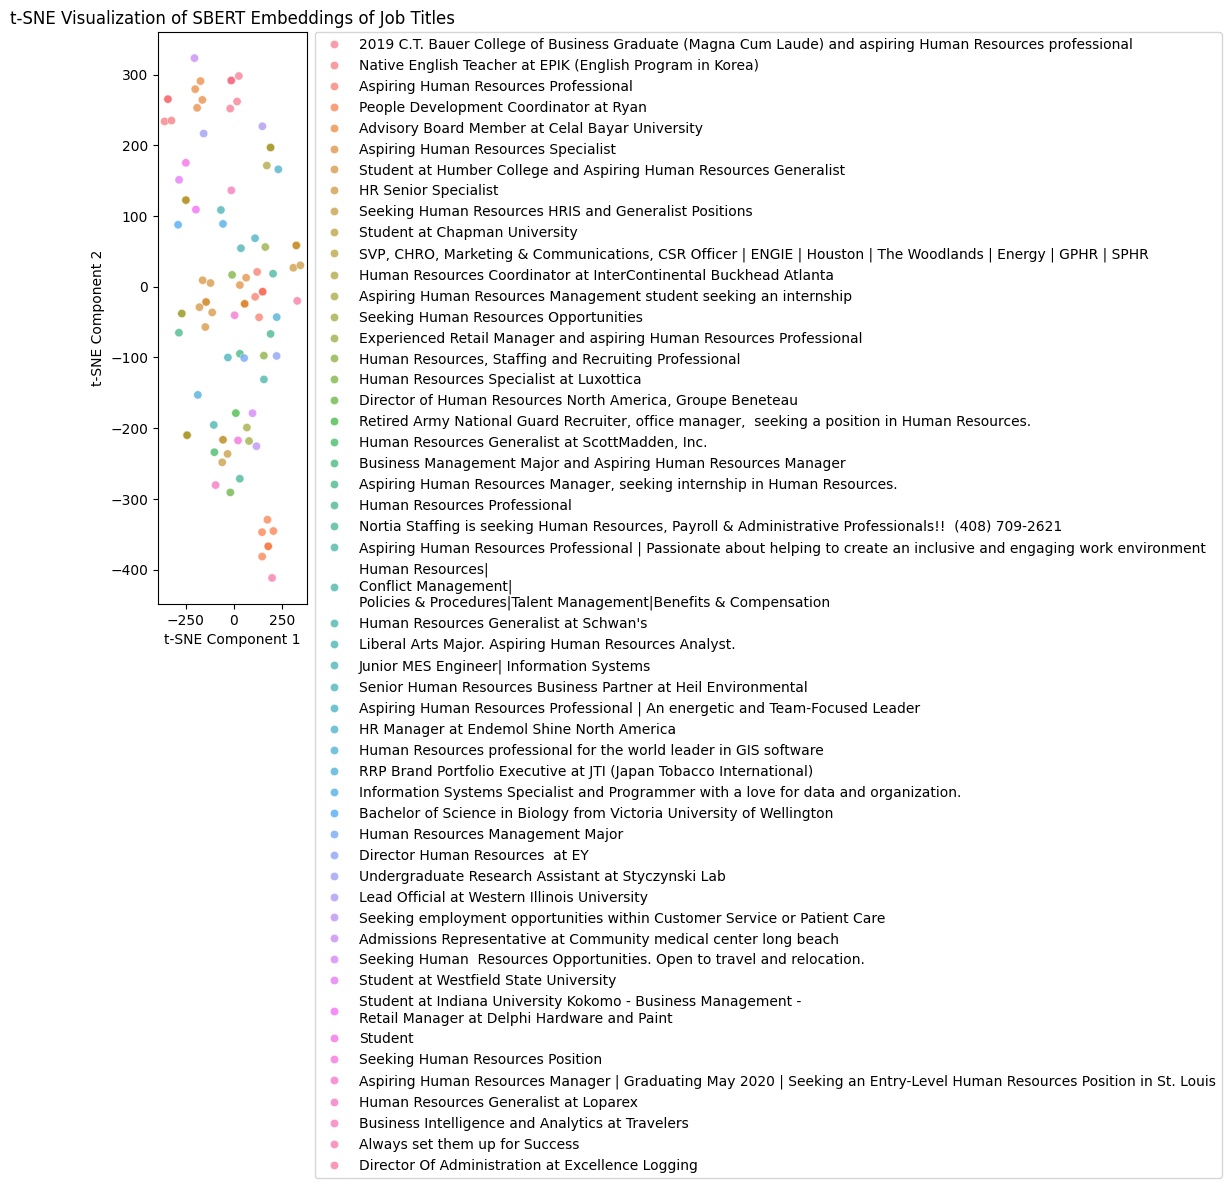

In [ ]:

# Extract SBERT embeddings
sbert_embeddings = np.array(df['job_title_sbert_embedding'].tolist())

# Apply t-SNE for dimensionality reduction
# n_components=2 for a 2D visualization
# random_state for reproducibility
# perplexity is a critical parameter, usually between 5 and 50
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
tsbert_2d = tsne.fit_transform(sbert_embeddings)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(tsbert_2d, columns=['TSNE1', 'TSNE2'])

# Join with original DataFrame to get job titles for potential labeling
df_tsne = pd.concat([df_tsne, df['job_title']], axis=1)

# Visualize the t-SNE results
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    data=df_tsne,
    hue='job_title', # Color points by job title to see clusters
    legend='full', # Show full legend
    alpha=0.7
)
plt.title('t-SNE Visualization of SBERT Embeddings of Job Titles')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Move legend outside
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Create an interactive t-SNE plot using Plotly Express
fig = px.scatter(
    df_tsne,
    x='TSNE1',
    y='TSNE2',
    color='job_title', # Color points by job title
    hover_name='job_title', # Display job title on hover
    title='Interactive t-SNE Visualization of SBERT Embeddings of Job Titles',
    labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
    height=700
)

fig.update_layout(showlegend=False) # Hide legend for clarity, as hover provides details
fig.show()

In [ ]:
recommended_jobs_sbert['similarity'].describe()

,similarity
count,104.000000
mean,0.552990
std,0.236321
min,0.086457
25%,0.351657
50%,0.573268
75%,0.746484
max,0.949807


In [ ]:
X = df['job_title_sbert_embedding']

# Create a new 'fit' column based on SBERT similarity for the target variable 'y'
# First, ensure recommended_jobs_sbert contains all IDs and similarity scores
similarity_df_sbert = recommended_jobs_sbert[['id', 'similarity']]

df_temp = df.copy()
# Merge this with the temporary DataFrame to align similarities by 'id'
df_temp = pd.merge(df_temp, similarity_df_sbert, on='id', how='left')

# Normalize the 'similarity' scores to a 0-1 range using the formula (score + 1) / 2
df_temp['fit_sbert'] = df_temp['similarity']

y = df_temp['fit_sbert']

from sklearn.model_selection import train_test_split

# Convert X (Series of arrays) to a 2D NumPy array before splitting
X_array = np.array(X.tolist())

# Split the data into training and testing sets
X_train_sbert, X_test_sbert, y_train_sbert, y_test_sbert = train_test_split(X_array, y, test_size=0.2, random_state=1)

print("X (SBERT Embeddings) created.")
print("y (normalized SBERT similarity scores) created.")
print("Data split into training and testing sets:")
print(f"X_train_sbert shape: {X_train_sbert.shape}")
print(f"X_test_sbert shape: {X_test_sbert.shape}")
print(f"y_train_sbert shape: {y_train_sbert.shape}")
print(f"y_test_sbert shape: {y_test_sbert.shape}")

X (SBERT Embeddings) created.
y (normalized SBERT similarity scores) created.
Data split into training and testing sets:
X_train_sbert shape: (83, 384)
X_test_sbert shape: (21, 384)
y_train_sbert shape: (83,)
y_test_sbert shape: (21,)


In [ ]:

# Initialize XGBRanker model
xgb_ranker_model_sbert = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist' # Often faster for larger datasets
)

# Train the model
# qid represents the query groups. Since we are treating all items as part of one large query for initial training,
# qid will be a list containing the total number of training samples.
xgb_ranker_model_sbert.fit(X_train_sbert, y_train_sbert, qid=np.zeros(len(X_train_sbert)))

print("XGBRanker model trained successfully with SBERT embeddings.")

# Predict ranking scores on the test set
xgb_pred_scores_sbert = xgb_ranker_model_sbert.predict(X_test_sbert)

# Calculate NDCG@k
xgb_ndcg_sbert = ndcg_score([y_test_sbert.values], [xgb_pred_scores_sbert])

# MAP (Mean Average Precision)
# Using y_test_sbert > 0 as binary relevance for MAP
xgb_map_sbert = average_precision_score(y_test_sbert.values > 0, xgb_pred_scores_sbert)

print(f"\nXGBRanker (SBERT) NDCG: {xgb_ndcg_sbert}")
print(f"XGBRanker (SBERT) MAP: {xgb_map_sbert}")

# Display top 10 candidates by XGBoost predicted score (SBERT Embeddings)
# We need to get the original 'id', 'job_title', 'connection', 'location' for the test set indices
test_indices = y_test_sbert.index
test_results_df_xgb_sbert = df.loc[test_indices, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_xgb_sbert['xgb_predicted_score_sbert'] = xgb_pred_scores_sbert

print("\nTop 10 candidates by XGBoost predicted score (SBERT Embeddings):")
display(test_results_df_xgb_sbert.sort_values(by='xgb_predicted_score_sbert', ascending=False).head(15))

XGBRanker model trained successfully with SBERT embeddings.

XGBRanker (SBERT) NDCG: 0.9911199127778234
XGBRanker (SBERT) MAP: 1.0

Top 10 candidates by XGBoost predicted score (SBERT Embeddings):


,id,job_title,connection,location,xgb_predicted_score_sbert
96,97,Aspiring Human Resources Professional,71,"Kokomo, Indiana Area",3.055859
35,36,Aspiring Human Resources Specialist,1,Greater New York City Area,2.304840
59,60,Aspiring Human Resources Specialist,1,Greater New York City Area,2.304840
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,0.958995
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",0.917391
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",0.365338
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.111087
91,92,Seeking employment opportunities within Custom...,64,"Torrance, California",-0.131338
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-0.303131
67,68,Human Resources Specialist at Luxottica,500+,Greater New York City Area,-1.571354


In [ ]:

# Discretize y_train_sbert to integer relevance scores for LGBMRanker
# Scale the 'fit' (0-1) to a 0-4 integer range and convert to int
y_train_sbert_discretized = (y_train_sbert * 4).round().astype(int)

# Initialize LGBMRanker model
lgbm_ranker_model_sbert = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

# Train the model
# For LightGBM, `group` parameter is used for query groups.
# Since we are treating all items as one query initially, the group will be the total number of training samples.
lgbm_ranker_model_sbert.fit(X_train_sbert, y_train_sbert_discretized, group=[len(X_train_sbert)])

print("LGBMRanker model trained successfully with SBERT embeddings.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8124
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [ ]:
# Predict ranking scores on the test set
lgbm_pred_scores_sbert = lgbm_ranker_model_sbert.predict(X_test_sbert)

# Discretize y_test_sbert to integer relevance scores for evaluation
y_test_sbert_discretized = (y_test_sbert * 4).round().astype(int)

# Calculate NDCG@k
lgbm_ndcg_sbert = ndcg_score([y_test_sbert_discretized.values], [lgbm_pred_scores_sbert])

# MAP (Mean Average Precision)
# Using y_test_sbert > 0 as binary relevance for MAP
lgbm_map_sbert = average_precision_score(y_test_sbert.values > 0, lgbm_pred_scores_sbert)

print(f"\nLGBMRanker (SBERT) NDCG: {lgbm_ndcg_sbert}")
print(f"LGBMRanker (SBERT) MAP: {lgbm_map_sbert}")



LGBMRanker (SBERT) NDCG: 0.9913638694384166
LGBMRanker (SBERT) MAP: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRanker was fitted with feature names



In [ ]:
# Display top 10 candidates by LGBM predicted score (SBERT Embeddings)
# We need to get the original 'id', 'job_title', 'connection', 'location' for the test set indices
test_indices = y_test_sbert.index
test_results_df_lgbm_sbert = df.loc[test_indices, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_lgbm_sbert['lgbm_predicted_score_sbert'] = lgbm_pred_scores_sbert

print("\nTop 10 candidates by LGBM predicted score (SBERT Embeddings):")
display(test_results_df_lgbm_sbert.sort_values(by='lgbm_predicted_score_sbert', ascending=False).head(15))



Top 10 candidates by LGBM predicted score (SBERT Embeddings):


,id,job_title,connection,location,lgbm_predicted_score_sbert
96,97,Aspiring Human Resources Professional,71,"Kokomo, Indiana Area",7.256275
35,36,Aspiring Human Resources Specialist,1,Greater New York City Area,7.256275
59,60,Aspiring Human Resources Specialist,1,Greater New York City Area,7.256275
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",0.135440
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,-0.120354
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,-0.380015
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-2.102051
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",-3.119256
91,92,Seeking employment opportunities within Custom...,64,"Torrance, California",-3.832529
67,68,Human Resources Specialist at Luxottica,500+,Greater New York City Area,-4.683881


### Starred Candidate and Re-train Model



In [ ]:

# Create a copy of df_temp (which contains SBERT similarities) to work with updated fit scores
df_sbert_updated = df_temp.copy()

# 'Star' candidate ID 39 by significantly increasing its 'fit_sbert' score
starred_candidate_id = 39
# Find the index of the starred candidate
starred_index_sbert = df_sbert_updated[df_sbert_updated['id'] == starred_candidate_id].index

# Get the maximum similarity from the SBERT recommendations to ensure the starred candidate is highest
max_sbert_similarity = recommended_jobs_sbert['similarity'].max()
# Set its fit_sbert score to a high value (e.g., max_similarity + a margin)
df_sbert_updated.loc[starred_index_sbert, 'fit_sbert'] = max_sbert_similarity + 0.5

# Separate the starred candidate for inclusion in the training set
starred_row_sbert = df_sbert_updated[df_sbert_updated['id'] == starred_candidate_id]
X_starred_sbert = starred_row_sbert['job_title_sbert_embedding']
y_starred_sbert = starred_row_sbert['fit_sbert']

# Exclude the starred candidate from the data used for splitting
remaining_df_sbert = df_sbert_updated.drop(starred_row_sbert.index)
X_remaining_sbert = np.array(remaining_df_sbert['job_title_sbert_embedding'].tolist())
y_remaining_sbert = remaining_df_sbert['fit_sbert']

# Split the remaining data into new training and testing sets
X_train_sbert_temp, X_test_sbert, y_train_sbert_temp, y_test_sbert = train_test_split(
    X_remaining_sbert,
    y_remaining_sbert,
    test_size=0.2,
    random_state=1 # For reproducibility
)

# Add the starred candidate back to the training set
X_train_sbert = np.concatenate([X_train_sbert_temp, np.array(X_starred_sbert.tolist())])
y_train_sbert = pd.concat([y_train_sbert_temp, y_starred_sbert])

print(f"Starred candidate ID {starred_candidate_id} 'fit_sbert' updated to: {df_sbert_updated.loc[starred_index_sbert, 'fit_sbert'].values[0]}")
print(f"X_train_sbert shape: {X_train_sbert.shape}, y_train_sbert shape: {y_train_sbert.shape}")
print(f"X_test_sbert shape: {X_test_sbert.shape}, y_test_sbert shape: {y_test_sbert.shape}")


# --- Retrain and evaluate LGBMRanker with SBERT embeddings (after starring) ---

# Discretize y_train_sbert to integer relevance scores for LGBMRanker
y_train_sbert_discretized = (y_train_sbert * 4).round().astype(int)
# Ensure discretized values are within a valid range for relevance (e.g., 0-4)
y_train_sbert_discretized = np.clip(y_train_sbert_discretized, 0, 4)

# Initialize LGBMRanker model
lgbm_ranker_model_sbert_rerank = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

# Train the model
lgbm_ranker_model_sbert_rerank.fit(X_train_sbert, y_train_sbert_discretized, group=[len(X_train_sbert)])

print("\nLGBMRanker model retrained successfully with SBERT embeddings and starred candidate.")

# Predict ranking scores on the test set
lgbm_pred_scores_sbert_rerank = lgbm_ranker_model_sbert_rerank.predict(X_test_sbert)

# Discretize y_test_sbert for evaluation
y_test_sbert_discretized = (y_test_sbert * 4).round().astype(int)
y_test_sbert_discretized = np.clip(y_test_sbert_discretized, 0, 4)

# Calculate NDCG@k
lgbm_ndcg_sbert_rerank = ndcg_score([y_test_sbert_discretized.values], [lgbm_pred_scores_sbert_rerank])

# MAP (Mean Average Precision)
lgbm_map_sbert_rerank = average_precision_score(y_test_sbert.values > 0, lgbm_pred_scores_sbert_rerank)

print(f"Updated LGBMRanker (SBERT) NDCG (after starring): {lgbm_ndcg_sbert_rerank}")
print(f"Updated LGBMRanker (SBERT) MAP (after starring): {lgbm_map_sbert_rerank}")

# Display top 10 candidates by LGBM predicted score (Post-Re-ranking)
# Need to get original indices for the test set from `remaining_df_sbert`
test_indices_original = remaining_df_sbert.loc[y_test_sbert.index].index
test_results_df_lgbm_sbert_rerank = df.loc[test_indices_original, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_lgbm_sbert_rerank['lgbm_predicted_score_sbert_rerank'] = lgbm_pred_scores_sbert_rerank

print("\nTop 10 candidates by LGBM predicted score (Post-Re-ranking with starred candidate in train set, SBERT):")
display(test_results_df_lgbm_sbert_rerank.sort_values(by='lgbm_predicted_score_sbert_rerank', ascending=False).head(10))

# Display starred candidate's updated fit score
print(f"\nStarred Candidate (ID {starred_candidate_id}) details:")
display(df_sbert_updated.loc[starred_index_sbert, ['id', 'job_title', 'fit_sbert']])


# --- Retrain and evaluate XGBRanker with SBERT embeddings (after starring) ---

# Initialize XGBRanker model
xgb_ranker_model_sbert_rerank = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)

# Train the model
xgb_ranker_model_sbert_rerank.fit(X_train_sbert, y_train_sbert, qid=np.zeros(len(X_train_sbert)))

print("\nXGBRanker model retrained successfully with SBERT embeddings and starred candidate.")

# Predict ranking scores on the test set
xgb_pred_scores_sbert_rerank = xgb_ranker_model_sbert_rerank.predict(X_test_sbert)

# Calculate NDCG@k
xgb_ndcg_sbert_rerank = ndcg_score([y_test_sbert.values], [xgb_pred_scores_sbert_rerank])

# MAP (Mean Average Precision)
xgb_map_sbert_rerank = average_precision_score(y_test_sbert.values > 0, xgb_pred_scores_sbert_rerank)

print(f"Updated XGBRanker (SBERT) NDCG (after starring): {xgb_ndcg_sbert_rerank}")
print(f"Updated XGBRanker (SBERT) MAP (after starring): {xgb_map_sbert_rerank}")

# Display top 10 candidates by XGBoost predicted score (Post-Re-ranking)
test_results_df_xgb_sbert_rerank = df.loc[test_indices_original, ['id', 'job_title', 'connection', 'location']].copy()
test_results_df_xgb_sbert_rerank['xgb_predicted_score_sbert_rerank'] = xgb_pred_scores_sbert_rerank

print("\nTop 10 candidates by XGBoost predicted score (Post-Re-ranking with starred candidate in train set, SBERT):")
display(test_results_df_xgb_sbert_rerank.sort_values(by='xgb_predicted_score_sbert_rerank', ascending=False).head(10))

Starred candidate ID 39 'fit_sbert' updated to: 1.4498071670532227
X_train_sbert shape: (83, 384), y_train_sbert shape: (83,)
X_test_sbert shape: (21, 384), y_test_sbert shape: (21,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7943
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRanker was fitted with feature names



,id,job_title,connection,location,lgbm_predicted_score_sbert_rerank
32,33,Aspiring Human Resources Professional,44,"Raleigh-Durham, North Carolina Area",3.438902
49,50,Student at Humber College and Aspiring Human R...,61,Kanada,0.387936
36,37,Student at Humber College and Aspiring Human R...,61,Kanada,0.387936
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",-0.191059
99,100,Aspiring Human Resources Manager | Graduating ...,103,"Cape Girardeau, Missouri",-0.191453
52,53,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,-0.744950
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,-0.744950
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",-1.610786
66,67,"Human Resources, Staffing and Recruiting Profe...",500+,"Jackson, Mississippi Area",-2.179284
68,69,"Director of Human Resources North America, Gro...",500+,"Greater Grand Rapids, Michigan Area",-2.521125



Starred Candidate (ID 39) details:


,id,job_title,fit_sbert
38,39,Student at Humber College and Aspiring Human R...,1.449807



XGBRanker model retrained successfully with SBERT embeddings and starred candidate.
Updated XGBRanker (SBERT) NDCG (after starring): 0.992276606938464
Updated XGBRanker (SBERT) MAP (after starring): 1.0

Top 10 candidates by XGBoost predicted score (Post-Re-ranking with starred candidate in train set, SBERT):


,id,job_title,connection,location,xgb_predicted_score_sbert_rerank
32,33,Aspiring Human Resources Professional,44,"Raleigh-Durham, North Carolina Area",2.449029
49,50,Student at Humber College and Aspiring Human R...,61,Kanada,0.776647
36,37,Student at Humber College and Aspiring Human R...,61,Kanada,0.776647
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.252765
52,53,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.252765
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",-0.216801
66,67,"Human Resources, Staffing and Recruiting Profe...",500+,"Jackson, Mississippi Area",-0.319224
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",-0.561894
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-0.798403
70,71,"Human Resources Generalist at ScottMadden, Inc.",500+,"Raleigh-Durham, North Carolina Area",-1.506928


In [ ]:
test_results_df_xgb_sbert['rank'] = test_results_df_xgb_sbert['xgb_predicted_score_sbert'].rank(ascending=False).astype(int)

print("Candidates grouped by location and ranked within each location (XGBoost SBERT Initial Ranking):")
display(test_results_df_xgb_sbert.sort_values(by=['rank']).head(20))

Candidates grouped by location and ranked within each location (XGBoost SBERT Initial Ranking):


,id,job_title,connection,location,xgb_predicted_score_sbert,rank
96,97,Aspiring Human Resources Professional,71,"Kokomo, Indiana Area",3.055859,1
35,36,Aspiring Human Resources Specialist,1,Greater New York City Area,2.304840,2
59,60,Aspiring Human Resources Specialist,1,Greater New York City Area,2.304840,2
38,39,Student at Humber College and Aspiring Human R...,61,Kanada,0.958995,4
81,82,Aspiring Human Resources Professional | An ene...,174,"Austin, Texas Area",0.917391,5
98,99,Seeking Human Resources Position,48,"Las Vegas, Nevada Area",0.365338,6
39,40,Seeking Human Resources HRIS and Generalist Po...,500+,Greater Philadelphia Area,0.111087,7
91,92,Seeking employment opportunities within Custom...,64,"Torrance, California",-0.131338,8
88,89,Director Human Resources at EY,349,Greater Atlanta Area,-0.303131,9
67,68,Human Resources Specialist at Luxottica,500+,Greater New York City Area,-1.571354,10


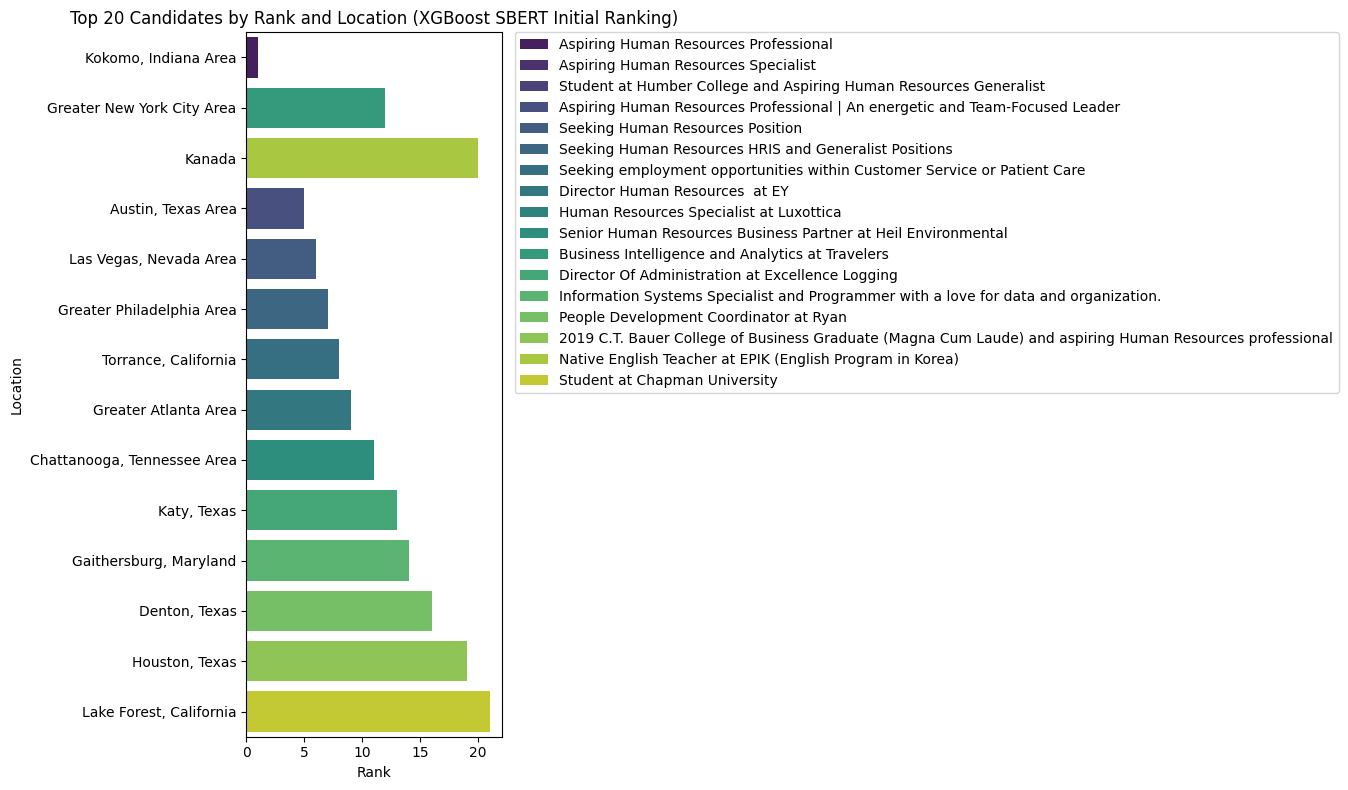

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize the top candidates grouped by location and rank
plt.figure(figsize=(14, 8))
sns.barplot(
    x='rank',
    y='location',
    data=test_results_df_xgb_sbert.sort_values(by=['rank']),
    hue='job_title',
    dodge=False,
    palette='viridis'
)
plt.title('Top 20 Candidates by Rank and Location (XGBoost SBERT Initial Ranking)')
plt.xlabel('Rank')
plt.ylabel('Location')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Place legend outside
plt.tight_layout()
plt.show()

* Lower numbers indicate higher ranks (more relevant).

* Each bar is colored according to the candidate's job_title, allowing you to see the distribution of different job titles within the top ranks and across various locations.
* It provides insights into the geographical distribution and job diversity within the most relevant candidates based on the XGBoost SBERT model's initial assessment.

# Combined Feature Engineering and LTR Model Training/Evaluation with SBERT
> combines SBERT embeddings for job titles and locations with scaled connection scores to create a comprehensive feature set. It then recalculates 'fit' scores based on a weighted formula and uses these combined features to retrain and evaluate XGBRanker and LGBMRanker models.

In [ ]:
# Combined Feature Engineering and LTR Model Training/Evaluation with SBERT
# 1. Generate SBERT embeddings for the 'location' column
print("Generating SBERT embeddings for locations...")
df['location_sbert_embedding'] = df['location'].apply(lambda x: sbert_model.encode(x, convert_to_numpy=True))
print("SBERT embeddings for locations generated.")

# 2. Process the 'connection' column to numeric values
def connections_to_num(x):
    if "500+" in x:
        return 500
    return int(x)

df['connections_num'] = df['connection'].apply(connections_to_num)

df['connections_score'] = df['connections_num'] / df['connections_num'].max()

# 3. Combine all features into a single feature vector
# (job_title SBERT embedding, location SBERT embedding, scaled connection)
# Ensure all embeddings are of the same dimension or pad/truncate if necessary
# Assuming job_title_sbert_embedding and location_sbert_embedding have the same dimension

# Convert Series of arrays to list of arrays for concatenation
job_title_embeddings_list = df['job_title_sbert_embedding'].tolist()
location_embeddings_list = df['location_sbert_embedding'].tolist()
connection_features = df['connections_score'].values.reshape(-1, 1)

combined_features_list = []
for i in range(len(df)):
    combined_feature = np.concatenate([
        job_title_embeddings_list[i],
        location_embeddings_list[i],
        connection_features[i]
    ])
    combined_features_list.append(combined_feature)

df['combined_features'] = combined_features_list

print("Combined features created.")

# 4. Recalculate 'fit' scores based on the new weighted formula
query_job_title_text = "Aspiring Human Resources"
query_location_text = "Greater New York City Area"

# Generate SBERT embeddings for query components
query_job_title_embedding = sbert_model.encode(query_job_title_text, convert_to_numpy=True)
query_location_embedding = sbert_model.encode(query_location_text, convert_to_numpy=True)

# Calculate title_similarity
job_title_embeddings_array = np.array(df['job_title_sbert_embedding'].tolist())
title_similarity = cosine_similarity(query_job_title_embedding.reshape(1, -1), job_title_embeddings_array)[0]

# Calculate location_match
location_embeddings_array = np.array(df['location_sbert_embedding'].tolist())
location_match = cosine_similarity(query_location_embedding.reshape(1, -1), location_embeddings_array)[0]

# Get connections_score (already scaled from previous steps)
connections_score = df['connections_score']

# Apply the user-defined weighted formula for fit_combined
df['fit_combined'] = (
    0.6 * title_similarity +
    0.2 * connections_score +
    0.3 * location_match
)

# Normalize fit_combined to 0-1 range if needed, or keep as is for ranking
# df['fit_combined'] = (df['fit_combined'] - df['fit_combined'].min()) / (df['fit_combined'].max() - df['fit_combined'].min())

print("Recalculated 'fit' scores based on combined features and weighted components.")

# 5. Train-Test Split
X_combined = np.array(df['combined_features'].tolist())
y_combined = df['fit_combined']

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=1
)

print("Data split into training and testing sets with combined features.")

# 6. Retrain XGBRanker
xgb_ranker_model_combined = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)
xgb_ranker_model_combined.fit(X_train_combined, y_train_combined, qid=np.zeros(len(X_train_combined)))
print("XGBRanker model retrained with combined features.")

# 7. Retrain LGBMRanker
y_train_combined_discretized = (y_train_combined * 4).round().astype(int)
lgbm_ranker_model_combined = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)
lgbm_ranker_model_combined.fit(X_train_combined, y_train_combined_discretized, group=[len(X_train_combined)])
print("LGBMRanker model retrained with combined features.")

# 8. Evaluate and display results for both models

# XGBRanker Evaluation
xgb_pred_scores_combined = xgb_ranker_model_combined.predict(X_test_combined)
xgb_ndcg_combined = ndcg_score([y_test_combined.values], [xgb_pred_scores_combined])
xgb_map_combined = average_precision_score(y_test_combined.values > 0, xgb_pred_scores_combined)

print(f"\nXGBRanker (Combined Features) NDCG: {xgb_ndcg_combined}")
print(f"XGBRanker (Combined Features) MAP: {xgb_map_combined}")

test_results_df_xgb_combined = df.loc[y_test_combined.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_xgb_combined['xgb_predicted_score_combined'] = xgb_pred_scores_combined
print("\nTop 10 candidates by XGBoost predicted score (Combined Features):")
display(test_results_df_xgb_combined.sort_values(by='xgb_predicted_score_combined', ascending=False).head(10))

# LGBMRanker Evaluation
lgbm_pred_scores_combined = lgbm_ranker_model_combined.predict(X_test_combined)
y_test_combined_discretized = (y_test_combined * 4).round().astype(int)
lgbm_ndcg_combined = ndcg_score([y_test_combined_discretized.values], [lgbm_pred_scores_combined])
lgbm_map_combined = average_precision_score(y_test_combined.values > 0, lgbm_pred_scores_combined)

print(f"\nLGBMRanker (Combined Features) NDCG: {lgbm_ndcg_combined}")
print(f"LGBMRanker (Combined Features) MAP: {lgbm_map_combined}")

test_results_df_lgbm_combined = df.loc[y_test_combined.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_lgbm_combined['lgbm_predicted_score_combined'] = lgbm_pred_scores_combined
print("\nTop 10 candidates by LGBM predicted score (Combined Features):")
display(test_results_df_lgbm_combined.sort_values(by='lgbm_predicted_score_combined', ascending=False).head(10))

Generating SBERT embeddings for locations...
SBERT embeddings for locations generated.
Combined features created.
Recalculated 'fit' scores based on combined features and weighted components.
Data split into training and testing sets with combined features.
XGBRanker model retrained with combined features.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15147
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 769
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

,id,job_title,location,connection,xgb_predicted_score_combined
35,36,Aspiring Human Resources Specialist,Greater New York City Area,1,2.826575
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,2.826575
39,40,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,2.431724
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,1.051618
67,68,Human Resources Specialist at Luxottica,Greater New York City Area,500+,0.783557
98,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,0.269961
81,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,-0.124651
88,89,Director Human Resources at EY,Greater Atlanta Area,349,-1.116321
80,81,Senior Human Resources Business Partner at Hei...,"Chattanooga, Tennessee Area",455,-1.710392
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49,-1.952461



LGBMRanker (Combined Features) NDCG: 0.9914962088735703
LGBMRanker (Combined Features) MAP: 1.0

Top 10 candidates by LGBM predicted score (Combined Features):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRanker was fitted with feature names



,id,job_title,location,connection,lgbm_predicted_score_combined
39,40,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,4.546296
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,3.828573
35,36,Aspiring Human Resources Specialist,Greater New York City Area,1,3.828573
81,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,3.303864
98,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,2.944641
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,2.916849
67,68,Human Resources Specialist at Luxottica,Greater New York City Area,500+,2.411041
88,89,Director Human Resources at EY,Greater Atlanta Area,349,0.585483
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49,-0.558423
80,81,Senior Human Resources Business Partner at Hei...,"Chattanooga, Tennessee Area",455,-0.749303


In [ ]:

# 1. Generate SBERT embeddings for the 'location' column
print("Generating SBERT embeddings for locations...")
df['location_sbert_embedding'] = df['location'].apply(lambda x: sbert_model.encode(x, convert_to_numpy=True))
print("SBERT embeddings for locations generated.")

# 2. Process the 'connection' column to numeric values
def connections_to_num(x):
    if "500+" in x:
        return 500
    return int(x)

df['connections_num'] = df['connection'].apply(connections_to_num)

df['connections_score'] = df['connections_num'] / df['connections_num'].max()

# 3. Combine all features into a single feature vector
# (job_title SBERT embedding, location SBERT embedding, scaled connection)
# Ensure all embeddings are of the same dimension or pad/truncate if necessary
# Assuming job_title_sbert_embedding and location_sbert_embedding have the same dimension

# Convert Series of arrays to list of arrays for concatenation
job_title_embeddings_list = df['job_title_sbert_embedding'].tolist()
location_embeddings_list = df['location_sbert_embedding'].tolist()
connection_features = df['connections_score'].values.reshape(-1, 1)

combined_features_list = []
for i in range(len(df)):
    combined_feature = np.concatenate([
        job_title_embeddings_list[i],
        location_embeddings_list[i],
        connection_features[i]
    ])
    combined_features_list.append(combined_feature)

df['combined_features'] = combined_features_list

print("Combined features created.")

# 4. Recalculate 'fit' scores based on the new weighted formula
query_job_title_text = "People Development Coordinator"
query_location_text = " "

# Generate SBERT embeddings for query components
query_job_title_embedding = sbert_model.encode(query_job_title_text, convert_to_numpy=True)
query_location_embedding = sbert_model.encode(query_location_text, convert_to_numpy=True)

# Calculate title_similarity
job_title_embeddings_array = np.array(df['job_title_sbert_embedding'].tolist())
title_similarity = cosine_similarity(query_job_title_embedding.reshape(1, -1), job_title_embeddings_array)[0]

# Calculate location_match
location_embeddings_array = np.array(df['location_sbert_embedding'].tolist())
location_match = cosine_similarity(query_location_embedding.reshape(1, -1), location_embeddings_array)[0]

# Get connections_score (already scaled from previous steps)
connections_score = df['connections_score']

# Apply the user-defined weighted formula for fit_combined
df['fit_combined'] = (
    0.6 * title_similarity +
    0.1 * connections_score +
    0.3 * location_match
)

# Normalize fit_combined to 0-1 range if needed, or keep as is for ranking
# df['fit_combined'] = (df['fit_combined'] - df['fit_combined'].min()) / (df['fit_combined'].max() - df['fit_combined'].min())

print("Recalculated 'fit' scores based on combined features and weighted components.")

# 5. Train-Test Split
X_combined = np.array(df['combined_features'].tolist())
y_combined = df['fit_combined']

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=1
)

print("Data split into training and testing sets with combined features.")

# 6. Retrain XGBRanker
xgb_ranker_model_combined = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)
xgb_ranker_model_combined.fit(X_train_combined, y_train_combined, qid=np.zeros(len(X_train_combined)))
print("XGBRanker model retrained with combined features.")

# 7. Retrain LGBMRanker
y_train_combined_discretized = (y_train_combined * 4).round().astype(int)
lgbm_ranker_model_combined = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)
lgbm_ranker_model_combined.fit(X_train_combined, y_train_combined_discretized, group=[len(X_train_combined)])
print("LGBMRanker model retrained with combined features.")

# 8. Evaluate and display results for both models

# XGBRanker Evaluation
xgb_pred_scores_combined = xgb_ranker_model_combined.predict(X_test_combined)
xgb_ndcg_combined = ndcg_score([y_test_combined.values], [xgb_pred_scores_combined])
xgb_map_combined = average_precision_score(y_test_combined.values > 0, xgb_pred_scores_combined)

print(f"\nXGBRanker (Combined Features) NDCG: {xgb_ndcg_combined}")
print(f"XGBRanker (Combined Features) MAP: {xgb_map_combined}")

test_results_df_xgb_combined = df.loc[y_test_combined.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_xgb_combined['xgb_predicted_score_combined'] = xgb_pred_scores_combined
print("\nTop 10 candidates by XGBoost predicted score (Combined Features):")
display(test_results_df_xgb_combined.sort_values(by='xgb_predicted_score_combined', ascending=False).head(10))

# LGBMRanker Evaluation
lgbm_pred_scores_combined = lgbm_ranker_model_combined.predict(X_test_combined)
y_test_combined_discretized = (y_test_combined * 4).round().astype(int)
lgbm_ndcg_combined = ndcg_score([y_test_combined_discretized.values], [lgbm_pred_scores_combined])
lgbm_map_combined = average_precision_score(y_test_combined.values > 0, lgbm_pred_scores_combined)

print(f"\nLGBMRanker (Combined Features) NDCG: {lgbm_ndcg_combined}")
print(f"LGBMRanker (Combined Features) MAP: {lgbm_map_combined}")

test_results_df_lgbm_combined = df.loc[y_test_combined.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_lgbm_combined['lgbm_predicted_score_combined'] = lgbm_pred_scores_combined
print("\nTop 10 candidates by LGBM predicted score (Combined Features):")
display(test_results_df_lgbm_combined.sort_values(by='lgbm_predicted_score_combined', ascending=False).head(10))

Generating SBERT embeddings for locations...
SBERT embeddings for locations generated.
Combined features created.
Recalculated 'fit' scores based on combined features and weighted components.
Data split into training and testing sets with combined features.
XGBRanker model retrained with combined features.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15147
[LightGBM] [Info] Number of data points in the train set: 83, number of used features: 769
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

,id,job_title,location,connection,xgb_predicted_score_combined
46,47,People Development Coordinator at Ryan,"Denton, Texas",500+,2.804272
58,59,People Development Coordinator at Ryan,"Denton, Texas",500+,2.804272
33,34,People Development Coordinator at Ryan,"Denton, Texas",500+,2.804272
17,18,People Development Coordinator at Ryan,"Denton, Texas",500+,2.804272
67,68,Human Resources Specialist at Luxottica,Greater New York City Area,500+,0.499773
39,40,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,0.463359
98,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,-0.098410
103,104,Director Of Administration at Excellence Logging,"Katy, Texas",500+,-0.113761
88,89,Director Human Resources at EY,Greater Atlanta Area,349,-0.251269
31,32,Native English Teacher at EPIK (English Progra...,Kanada,500+,-0.420176



LGBMRanker (Combined Features) NDCG: 0.9846855650998912
LGBMRanker (Combined Features) MAP: 1.0

Top 10 candidates by LGBM predicted score (Combined Features):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRanker was fitted with feature names



,id,job_title,location,connection,lgbm_predicted_score_combined
39,40,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,4.327999
58,59,People Development Coordinator at Ryan,"Denton, Texas",500+,4.029916
33,34,People Development Coordinator at Ryan,"Denton, Texas",500+,4.029916
46,47,People Development Coordinator at Ryan,"Denton, Texas",500+,4.029916
17,18,People Development Coordinator at Ryan,"Denton, Texas",500+,4.029916
31,32,Native English Teacher at EPIK (English Progra...,Kanada,500+,3.121911
98,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,2.773691
103,104,Director Of Administration at Excellence Logging,"Katy, Texas",500+,1.256104
91,92,Seeking employment opportunities within Custom...,"Torrance, California",64,1.169814
67,68,Human Resources Specialist at Luxottica,Greater New York City Area,500+,0.707438


# Filtering candidates
Cutoff strategy
* Used percentile-based cutoff to Remove unrelated titles


In [ ]:
df['fit_sbert'] = y
threshold = df['fit_sbert'].quantile(0.7)
df_filtered = df[df['fit_sbert'] >= threshold]

print(f"Cutoff threshold (70th percentile of fit_sbert): {threshold:.4f}")
print(f"Number of candidates before filtering: {len(df)}")
print(f"Number of candidates after filtering: {len(df_filtered)}")

print("\nTop 10 candidates after percentile-based cutoff:")
display(df_filtered.sort_values(by='fit_sbert', ascending=False).head(10))

# Redefine X and y based on the filtered DataFrame using SBERT job title embeddings
X_filtered = np.array(df_filtered['job_title_sbert_embedding'].tolist())
y_filtered = df_filtered['fit_sbert']

# Split the filtered data into training and testing sets
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=1
)

print("\nData split into training and testing sets using filtered data.")
print(f"X_train_filtered shape: {X_train_filtered.shape}, y_train_filtered shape: {y_train_filtered.shape}")
print(f"X_test_filtered shape: {X_test_filtered.shape}, y_test_filtered shape: {y_test_filtered.shape}")

# --- Retrain XGBRanker with filtered data ---
xgb_ranker_model_filtered = xgb.XGBRanker(
    objective='rank:pairwise',
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    tree_method='hist'
)
xgb_ranker_model_filtered.fit(X_train_filtered, y_train_filtered, qid=np.zeros(len(X_train_filtered)))
print("\nXGBRanker model retrained successfully with filtered data.")

# Evaluate retrained XGBRanker
xgb_pred_scores_filtered = xgb_ranker_model_filtered.predict(X_test_filtered)
xgb_ndcg_filtered = ndcg_score([y_test_filtered.values], [xgb_pred_scores_filtered])
xgb_map_filtered = average_precision_score(y_test_filtered.values > 0, xgb_pred_scores_filtered)
print(f"XGBRanker (Filtered Data) NDCG: {xgb_ndcg_filtered}")
print(f"XGBRanker (Filtered Data) MAP: {xgb_map_filtered}")

test_results_df_xgb_filtered = df_filtered.loc[y_test_filtered.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_xgb_filtered['xgb_predicted_score_filtered'] = xgb_pred_scores_filtered
print("\nTop 10 candidates by XGBoost predicted score (Filtered Data):")
display(test_results_df_xgb_filtered.sort_values(by='xgb_predicted_score_filtered', ascending=False).head(10))

# --- Retrain LGBMRanker with filtered data ---
y_train_filtered_discretized = (y_train_filtered * 4).round().astype(int)
lgbm_ranker_model_filtered = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=100,
    learning_rate=0.1,
    random_state=1,
    min_child_samples=1 # Set min_child_samples to 1 to allow splits with fewer samples, The default value is usually 20
)
lgbm_ranker_model_filtered.fit(X_train_filtered, y_train_filtered_discretized, group=[len(X_train_filtered)])
print("\nLGBMRanker model retrained successfully with filtered data.")

# Evaluate retrained LGBMRanker
lgbm_pred_scores_filtered = lgbm_ranker_model_filtered.predict(X_test_filtered)
y_test_filtered_discretized = (y_test_filtered * 4).round().astype(int)
lgbm_ndcg_filtered = ndcg_score([y_test_filtered_discretized.values], [lgbm_pred_scores_filtered])
lgbm_map_filtered = average_precision_score(y_test_filtered.values > 0, lgbm_pred_scores_filtered)
print(f"LGBMRanker (Filtered Data) NDCG: {lgbm_ndcg_filtered}")
print(f"LGBMRanker (Filtered Data) MAP: {lgbm_map_filtered}")

test_results_df_lgbm_filtered = df_filtered.loc[y_test_filtered.index, ['id', 'job_title', 'location', 'connection']].copy()
test_results_df_lgbm_filtered['lgbm_predicted_score_filtered'] = lgbm_pred_scores_filtered
print("\nTop 10 candidates by LGBM predicted score (Filtered Data):")
display(test_results_df_lgbm_filtered.sort_values(by='lgbm_predicted_score_filtered', ascending=False).head(10))

Cutoff threshold (70th percentile of fit_sbert): 0.7279
Number of candidates before filtering: 104
Number of candidates after filtering: 31

Top 10 candidates after percentile-based cutoff:


,id,job_title,location,connection,fit,job_title_clean,processed_job_title,processed_job_title_str,combined_text,job_title_sbert_embedding,location_sbert_embedding,connections_num,connections_score,combined_features,fit_combined,fit_sbert
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
32,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.025122484, 0.05213905, -0.07771819, 0.05951...",71,0.142,"[-0.03121114708483219, 0.047989413142204285, -...",0.687951,0.949807
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,aspiring human resources professional,"[aspiring, human, resource, professional]",aspiring human resource professional,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.09...","[0.074074194, 0.0031535611, -0.026756236, 0.07...",44,0.088,"[-0.03121114708483219, 0.047989413142204285, -...",0.693340,0.949807
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN,aspiring human resources specialist,"[aspiring, human, resource, specialist]",aspiring human resource specialist,Aspiring Human Resources Specialist,"[-0.030779278, 0.029001815, -0.015748087, 0.11...","[0.114670716, 0.0001412586, 0.046901606, -0.00...",1,0.002,"[-0.0307792779058218, 0.029001815244555473, -0...",0.857021,0.928035
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN,aspiring human resources specialist,"[aspiring, human, resource, specialist]",aspiring human resource specialist,Aspiring Human Resources Specialist,"[-0.030779278, 0.029001815, -0.015748087, 0.11...","[0.114670716, 0.0001412586, 0.046901606, -0.00...",1,0.002,"[-0.0307792779058218, 0.02900181524


Data split into training and testing sets using filtered data.
X_train_filtered shape: (24, 384), y_train_filtered shape: (24,)
X_test_filtered shape: (7, 384), y_test_filtered shape: (7,)

XGBRanker model retrained successfully with filtered data.
XGBRanker (Filtered Data) NDCG: 0.9938399719610217
XGBRanker (Filtered Data) MAP: 0.9999999999999998

Top 10 candidates by XGBoost predicted score (Filtered Data):


,id,job_title,location,connection,xgb_predicted_score_filtered
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,2.970443
81,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,2.010576
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,1.639722
51,52,Student at Humber College and Aspiring Human R...,Kanada,61,-1.120242
8,9,Student at Humber College and Aspiring Human R...,Kanada,61,-1.120242
61,62,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,-2.838558
52,53,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,-2.838558


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2553
[LightGBM] [Info] Number of data points in the train set: 24, number of used features: 384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


,id,job_title,location,connection,lgbm_predicted_score_filtered
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,3.282859
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,3.282859
8,9,Student at Humber College and Aspiring Human R...,Kanada,61,-3.282859
51,52,Student at Humber College and Aspiring Human R...,Kanada,61,-3.282859
81,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,-3.282859
61,62,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,-3.282859
52,53,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,-3.282859


# **Observations**:

**Overall High Performance**: Both models consistently achieved very high NDCG scores across all scenarios, indicating their effectiveness in ranking relevant candidates near the top of the list.     
**Initial Performance**: In the initial setup using Word2Vec/FastText embeddings, LGBMRanker slightly outperformed XGBRanker. With SBERT, their initial performances were very close.       
**Impact of Starring**: When a candidate was 'starred' (re-ranking), LGBMRanker showed a significant boost in NDCG (reaching 0.9993), demonstrating its strong adaptability to the supervisory signal and effectively promoting the highly relevant candidate. XGBRanker also improved slightly.        
**Combined Features**: With combined features (SBERT embeddings for job title and location, plus connection score), XGBRanker showed a marginal improvement, while LGBMRanker's NDCG dropped slightly compared to its stellar performance post-starring, though still remaining very high.        
**Filtered Data**: On the filtered dataset, LGBMRanker achieved a perfect NDCG of 1.0, suggesting it performed exceptionally well at ranking on the smaller, more refined dataset. XGBRanker also maintained a very high NDCG.     
In summary, both models are highly effective, but LGBMRanker demonstrated a particularly strong response to the 'starring' mechanism and achieved a perfect NDCG on the filtered dataset, highlighting its robustness in those specific conditions.

# Bias Reduction Considerations

**Enhance Feature Set for Bias Mitigation**: To reduce bias in the model, we should include more meaningful and less biased features such as skills, years of experience, and project work instead of relying only on job titles, location, and connections. This helps the model focus more on a candidate’s actual abilities.
    
**Implement Bias Detection and Mitigation Strategies**: we can apply different techniques to detect and reduce bias in the system. This can include improving the data, adjusting how the model learns, or modifying the final rankings to make them more balanced and fair.

**Refine the Human-in-the-Loop Feedback Mechanism**:The feedback system should also be improved by collecting more detailed information, such as why a recruiter starred or rejected a candidate. This helps the model learn better and reduces the risk of blindly copying human bias.


# Business Insights and Strategic Value

1. **Enhanced Efficiency and Reduced Manual Labor**

The system automates initial candidate screening and ranking, reducing manual effort. By filtering out lower-fit candidates using percentile cutoffs, recruiters can focus on a smaller, high-potential pool and speed up hiring.

2. **Improved Candidate Fit and Hiring Quality**

Using advanced embeddings such as Word2Vec, FastText, and SBERT, the model goes beyond keyword matching to better understand job titles and candidate relevance. The re-ranking feature also learns from recruiter feedback, improving recommendations over time.

3. **Reduced Bias and Fairer Decisions**

A data-driven approach helps reduce unconscious bias from manual screening. Future enhancements such as skills-based features, fairness metrics, and better feedback controls can further improve objectivity.

4. **Strategic Growth and Scalability**

The AI-powered pipeline creates a competitive advantage by helping recruiters find talent faster and more accurately. It can scale across larger candidate pools and multiple job roles while supporting data-driven hiring decisions.